In [1]:
using CairoMakie
using CSV
using DataFrames
using DelimitedFiles

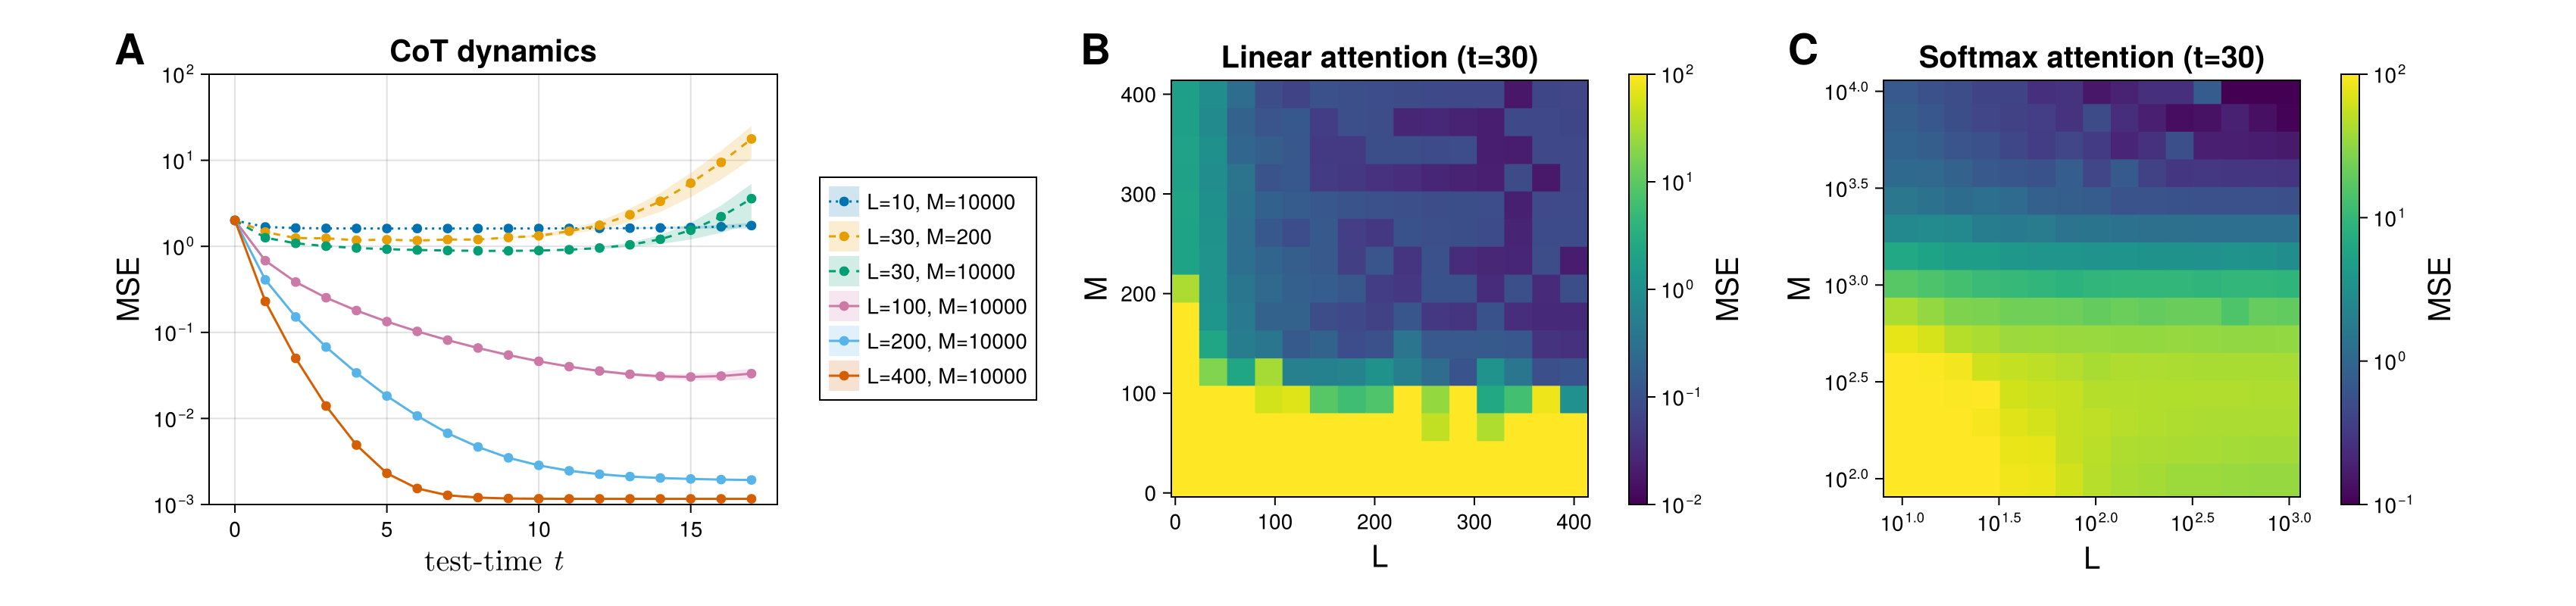

CairoMakie.Screen{IMAGE}


In [7]:

# ===== hard-coded paths =====
LD_DIR = "/home/takanami/cot_asymptotics/linear_dynamics/results/linear_dynamics_20260417_170446"
LH_DIR = "/home/takanami/cot_asymptotics/linear_heatmap/results/latest_linear_heatmap"
SH_DIR = "/home/takanami/cot_asymptotics/softmax_heatmap/results/softmax_heatmap_20260417_195912"

function read_config(path::String)
    cfg = Dict{String, String}()
    for line in eachline(path)
        s = strip(line)
        isempty(s) && continue
        occursin("=", s) || continue
        k, v = split(s, "=", limit = 2)
        cfg[strip(k)] = strip(v)
    end
    return cfg
end

# ===== A: linear_dynamics =====
ld_df = CSV.read(joinpath(LD_DIR, "summary.csv"), DataFrame)
ld_pairs = sort(unique(select(ld_df, [:n, :m])))

# ===== B: linear_heatmap =====
lh_cfg = read_config(joinpath(LH_DIR, "config.txt"))
lh_m = vec(Int.(readdlm(joinpath(LH_DIR, "M_list.csv"), ',', Float64)))
lh_n = vec(Int.(readdlm(joinpath(LH_DIR, "N_list.csv"), ',', Float64)))
lh_t = vec(Int.(readdlm(joinpath(LH_DIR, "EVAL_T_list.csv"), ',', Float64)))
lh_t_heat = 30
lh_heat = readdlm(joinpath(LH_DIR, "heat_t$(lh_t_heat).csv"), ',', Float64)

# ===== C: softmax_heatmap =====
sh_cfg = read_config(joinpath(SH_DIR, "config.txt"))
sh_m = vec(Int.(readdlm(joinpath(SH_DIR, "M_list.csv"), ',', Float64)))
sh_n = vec(Int.(readdlm(joinpath(SH_DIR, "N_list.csv"), ',', Float64)))
sh_t = vec(Int.(readdlm(joinpath(SH_DIR, "EVAL_T_list.csv"), ',', Float64)))
sh_t_heat = 30
sh_heat = readdlm(joinpath(SH_DIR, "heat_t$(sh_t_heat).csv"), ',', Float64)


fig = Figure(size = (1700, 400))
titlesize = 20
labelsize = 20

# ---------- A ----------
axA = Axis(
    fig[1, 1],
    xlabel = L"test-time $t$",
    ylabel = "MSE",
    title = "CoT dynamics",
    limits = (nothing, nothing, 1e-3 , 100.0),
    xlabelsize = labelsize,
    ylabelsize = labelsize,
    titlesize = titlesize,
    yscale = log10, 
)
linetypes = [:solid, :dash, :dot, :dashdot]
colors = Makie.wong_colors()
for (k, row) in enumerate(eachrow(ld_pairs))
    if (row.n, row.m) == (600, 10000) || (row.n, row.m) == (800, 10000)
        continue
    end

    # type 
    type = nothing
    if (row.n, row.m) == (10, 10000)
        type = "saturation"
        linetype = :dot   
    elseif (row.n, row.m) == (30, 200) || (row.n, row.m) == (30, 10000)
        type = "overthinking"
        linetype = :dash
    else
        type = "decay"
        linetype = :solid
    end

    sub = sort(ld_df[(ld_df.n .== row.n) .& (ld_df.m .== row.m), :], :t)
    t = Float64.(sub.t)
    meanv = Float64.(sub.mean_loss)
    sev   = Float64.(sub.se_loss)
    lower = max.(meanv .- sev, eps(Float64))
    upper = meanv .+ sev
    c        = colors[mod1(k, length(colors))]
    
    t_end    = min(18, length(t))
    band!(axA, t[1:t_end], lower[1:t_end], upper[1:t_end], color = (c, 0.18), label = "L=$(row.n), M=$(row.m)")
    lines!(axA, t[1:t_end], meanv[1:t_end], color = c, linestyle = linetype, label = "L=$(row.n), M=$(row.m)")
    scatter!(axA, t[1:t_end], meanv[1:t_end], color = c, label = "L=$(row.n), M=$(row.m)")
end
Legend(fig[1, 2], axA, merge = true)

# ---------- B ----------
axB = Axis(
    fig[1, 3],
    xlabel = "L",
    ylabel = "M",
    title = "Linear attention (t=$(lh_t_heat))",
    aspect = DataAspect(),
    titlesize = titlesize,
    xlabelsize = labelsize,
    ylabelsize = labelsize,
)
hmB = heatmap!(axB, lh_n, lh_m, lh_heat, colormap = :viridis, colorrange = (10^(-2), 10^2), colorscale = log10)
Colorbar(fig[1, 4], hmB, label = "MSE", labelsize = labelsize)

# ---------- C ----------
axC = Axis(
    fig[1, 5],
    xlabel = "L",
    ylabel = "M",
    title = "Softmax attention (t=$(sh_t_heat))",
    xscale = log10,
    yscale = log10,
    aspect = 1,
    titlesize = titlesize,
    xlabelsize = labelsize,
    ylabelsize = labelsize,
)
hmC = heatmap!(axC, sh_n, sh_m, sh_heat, 
    colormap = :viridis, 
    colorscale = log10, 
    colorrange = (10^(-1), 10^2),
)
Colorbar(fig[1, 6], hmC, label = "MSE", labelsize = labelsize)

# ---------- A/B/C labels ----------
Label(fig[1, 1, TopLeft()], "A", fontsize = 28, font = :bold, padding = (0, 40, 0, 0))
Label(fig[1, 3, TopLeft()], "B", fontsize = 28, font = :bold, padding = (0, 40, 0, 0))
Label(fig[1, 5, TopLeft()], "C", fontsize = 28, font = :bold, padding = (0, 40, 0, 0))


colsize!(fig.layout, 1, Relative(0.3))  # A
colsize!(fig.layout, 2, Fixed(160))       # Legend
colsize!(fig.layout, 3, Relative(0.22))   # B
colsize!(fig.layout, 4, Fixed(25))        # CbarB
colsize!(fig.layout, 5, Relative(0.22))   # C
colsize!(fig.layout, 6, Fixed(25))        # CbarC
colgap!(fig.layout, 20)

#save("linear_dynamics.pdf", fig)
display(fig)